# Model Training - VGG16 Transfer Learning

Fine-tune VGG16 pretrained on ImageNet for the Oxford 102 Flower Dataset.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Load datasets
checkpoint = torch.load(
    '../data/processed_datasets.pth',
    map_location='cpu',
    weights_only=False  # Required for checkpoints containing ImageFolder objects
)
train_dataset = checkpoint['train_dataset']
val_dataset = checkpoint['val_dataset']
test_dataset = checkpoint['test_dataset']

# Create dataloaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 32
Validation batches: 32
Test batches: 193


In [3]:
# Load pretrained VGG16 and modify classifier
def create_vgg16_model(num_classes=102, freeze_features=True):
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    
    # Freeze feature layers
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False
    
    # Replace classifier
    num_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_features, num_classes)
    
    return model

model = create_vgg16_model(num_classes=102, freeze_features=True)
model = model.to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [4]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [5]:
# Training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader), correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader), correct / total

In [6]:
# Training loop
num_epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    start_time = time.time()
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    scheduler.step()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, "
          f"Time: {time.time()-start_time:.2f}s")

Epoch 1/10 - Train Loss: 4.8026, Train Acc: 0.0147, Val Loss: 4.4728, Val Acc: 0.0343, Time: 1599.01s
Epoch 2/10 - Train Loss: 4.5317, Train Acc: 0.0265, Val Loss: 4.1265, Val Acc: 0.0980, Time: 1185.65s
Epoch 3/10 - Train Loss: 4.2521, Train Acc: 0.0686, Val Loss: 3.8026, Val Acc: 0.1127, Time: 1108.36s
Epoch 4/10 - Train Loss: 4.0498, Train Acc: 0.0941, Val Loss: 3.4524, Val Acc: 0.1745, Time: 978.71s
Epoch 5/10 - Train Loss: 3.6631, Train Acc: 0.1412, Val Loss: 2.9071, Val Acc: 0.2931, Time: 983.88s
Epoch 6/10 - Train Loss: 2.9727, Train Acc: 0.2784, Val Loss: 2.5769, Val Acc: 0.4088, Time: 988.21s
Epoch 7/10 - Train Loss: 2.7536, Train Acc: 0.3167, Val Loss: 2.4032, Val Acc: 0.4353, Time: 1260.54s
Epoch 8/10 - Train Loss: 2.5895, Train Acc: 0.3480, Val Loss: 2.2408, Val Acc: 0.4745, Time: 1266.56s
Epoch 9/10 - Train Loss: 2.3172, Train Acc: 0.4029, Val Loss: 2.0908, Val Acc: 0.5088, Time: 1398.00s
Epoch 10/10 - Train Loss: 2.1400, Train Acc: 0.4216, Val Loss: 1.9266, Val Acc: 0.535

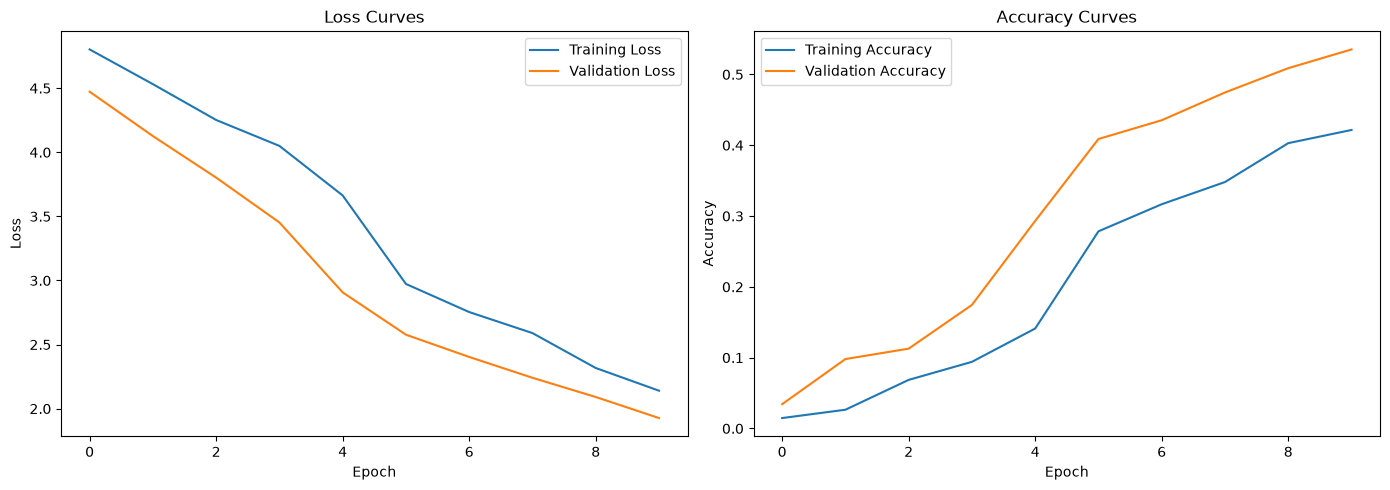

In [7]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Training Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()

ax2.plot(train_accs, label='Training Accuracy')
ax2.plot(val_accs, label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves')
ax2.legend()

plt.tight_layout()
plt.show()

In [9]:
# Save model
model_path = Path('../models/vgg16_flowers102.pth')
model_path.parent.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), model_path)
print("VGG16 model saved successfully!")

VGG16 model saved successfully!
